# Batch a function with vmap

CPU companion; no accelerator is required. TPU execution not validated.

- Write and check a single-example function before batching it.
- Predict vmap input/output axes and distinguish shared parameters from mapped data.
- Verify batched results against a Python-loop reference.
- Relate per-example loss gradients to the gradient of a batch mean.

You have a prediction function that works for one example. Now you need it for a batch. Rather than keep two versions of the model in sync, we’ll tell JAX which input axis contains examples. You’ll compare vmap with a short Python loop and learn which inputs stay shared.

## The idea

vmap transforms a function by mapping designated input axes and collecting an output axis. Start with $\hat y=w^\mathsf{T}x$. Both inputs to the single-example function have shape $(D,)$, and the result is scalar. A data batch has shape $(B, D)$. With `in_axes=(None, 0)`, the weight remains shared while axis $0$ of the data supplies one example. The batched output has shape $(B,)$.

The mental model is a loop over examples, but JAX applies batching rules to the operations rather than requiring you to write that loop. It is a transformation, not a claim of multiple devices, independent processes, or automatic speedup. Start with shape and value correctness before asking about performance.

## Write down the axis contract

There are three independent questions: which dimension represents examples, which inputs should be repeated unchanged, and where should the collected output axis go? $B$ and $D$ are labels for your reasoning, not named dimensions enforced by JAX.

For the worked example, shared weight is $(2,)$, data is $(3, 2)$, and predictions are $(3,)$. The first row $[1, 1]$ produces $2\cdot1-1\cdot1=1$. The second row $[2, 3]$ also produces $1$. The third $[4, 0]$ produces $8$. Calculate those values before reading the batched call.

```text
single: (D,), (D,) → ()
batched: shared (D,), mapped (B,D) → (B,)
```

## Build a reference that is easy to trust

A small Python loop makes the mapping literal: select each data row, call the original function, and stack its results. Keep that reference for tests even if it is not the production implementation. A matrix-vector product is a second independent formulation for this linear model.

Agreement among the loop, vmap, and matrix product checks different ways of describing the same computation. It does not prove that arbitrary future nonlinear models or new axis conventions are correct. Include asymmetric shapes and distinct row values so a transposition or accidentally shared example is easy to detect.

## Shared does not mean copied or frozen

None in in_axes tells the transformation that an argument has no mapped axis at this level. Every logical example sees the same parameter value. It is still an argument: you can pass a different weight on the next call. It is not a static compilation argument, and None says nothing about whether a gradient can be computed with respect to it.

Setting both arguments to axis $0$ would pair one weight row with one example row. That is useful for an ensemble or a collection of separate models, but it is a different computation from a single shared model. All mapped axes at the same vmap level must have compatible sizes.

## Change layout without changing semantics

Some data arrive with examples in columns: shape $(D, B)$. Mapping axis $1$ selects one column at a time and restores the same single-example shape $(D,)$. in_axes describes that layout. out_axes controls where the new output batch axis is inserted; it does not automatically transpose existing feature dimensions.

For a scalar prediction, output collection gives a vector either way. For a vector-valued feature function, the default produces $(B, K)$; `out_axes=1` gives $(K, B)$. Keep these distinctions explicit at boundaries between a data loader, model, and loss.

## Separate per-example and aggregate gradients

The gradient of a single prediction with respect to its weights is just the input vector. That is a useful first test but not a training loss gradient. A per-example squared error contributes $2(\hat y-y)$ times the input vector. Mapping grad over examples produces an array of shape $(B, D)$.

The gradient of the mean loss has shape $(D,)$. For independent example losses and a plain mean reduction, it equals the mean of the per-example gradients. This equivalence is an important check, and it explains why storing all per-example gradients is not necessary for ordinary mean-loss training. Those arrays can be much larger than the aggregate gradient.

## Compose transformations around the question

`vmap(grad(single_loss))` asks for a gradient per example. `grad(mean(vmap(single_loss)))` asks for the gradient of a batch objective. Both can be useful, but their output shapes and memory needs differ. Once values match independent references, jit can compile the batched transformed function.

Choose the mathematical quantity first and the transformation order second. Do not copy a composition from a tutorial without checking whether it returns predictions, sensitivities, per-example gradients, or a reduced parameter update.

## Run the example

In [1]:
import jax
import jax.numpy as jnp
def predict(weight, x):
    return jnp.dot(weight, x)
weight = jnp.array([2., -1.])
batch = jnp.array([[1., 1.], [2., 3.], [4., 0.]])
batched = jax.vmap(predict, in_axes=(None, 0))
print(batched(weight, batch))
assert jnp.allclose(batched(weight, batch), jnp.array([1.,1.,8.]))

[1. 1. 8.]


Expected: [$1$. $1$. $8$.]

## Vectorization keeps one result per row

Predict: Which observation produces the largest prediction?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [2]:
visual_data = {'kind': 'bar', 'labels': ['row 0', 'row 1', 'row 2'], 'ylabel': 'prediction', 'series': [{'label': 'vmap output', 'y': batched(weight, batch).tolist()}]}

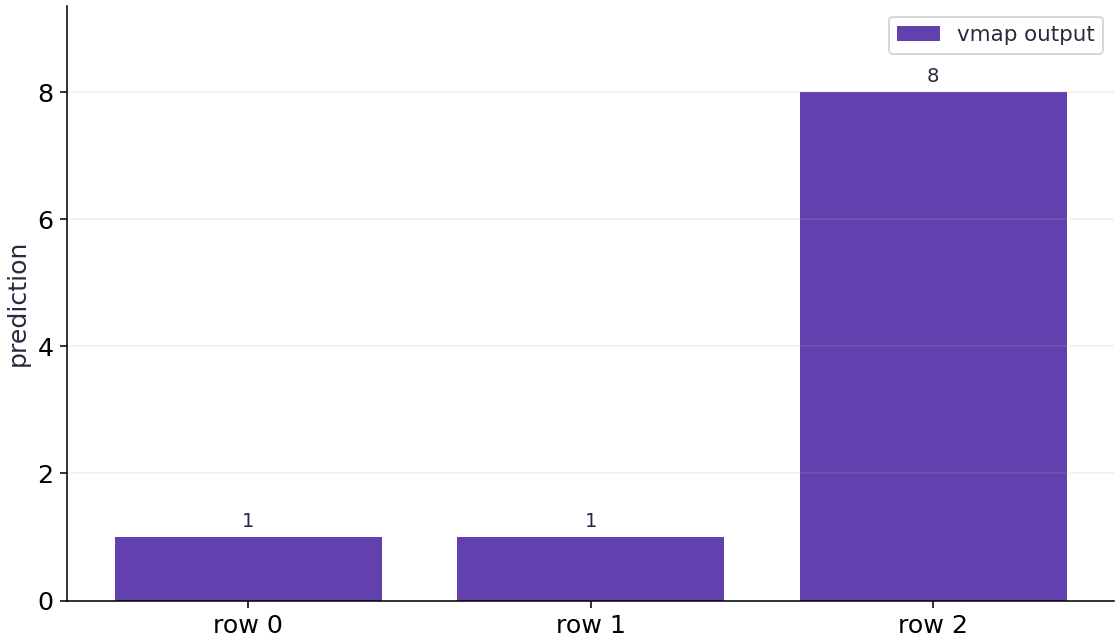

In [3]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Each bar belongs to one input row, and its height is that row’s scalar prediction. Reading left to right gives $1$, $1$, and $8$. The horizontal positions are row labels, not successive training steps.

The same weights $(2,-1)$ are used for every row. The first input $(1,1)$ gives $2-1=1$; the second $(2,3)$ gives $4-3=1$; the third $(4,0)$ gives $8-0=8$.

### Connect it to the computation

`vmap` applies the single-example dot product across the batch and keeps one answer per row. Equal heights for the first two bars do not mean those inputs were equal; different inputs can have the same dot product.

There are three outputs because there are three observations. Summing across the whole batch would instead collapse these answers into one scalar. The figure verifies what vectorization computes; the bar heights say nothing about how long it takes.

## Verify against a loop and a matrix product

Predict: Predict the values and output shape. Which reference will catch an incorrectly mapped parameter axis?

In [4]:
loop_predictions = jnp.stack([predict(weight, row) for row in batch])
vector_predictions = batched(weight, batch)
matrix_predictions = batch @ weight
assert vector_predictions.shape == (3,)
assert jnp.allclose(vector_predictions, loop_predictions)
assert jnp.allclose(vector_predictions, matrix_predictions)
print("loop / vmap / matmul:", loop_predictions, vector_predictions, matrix_predictions)

loop / vmap / matmul: [1. 1. 8.] [1. 1. 8.] [1. 1. 8.]


Expected: All three formulations produce $[1, 1, 8]$.

The loop makes example selection explicit; the matrix product checks an independent formulation. Keep both as bounded checks of this linear case.

## Move the example axis

Predict: Transpose the batch to shape $(2, 3)$. Which axis must be mapped to give a length-2 input to predict?

In [5]:
column_batch = batch.T
column_predict = jax.vmap(predict, in_axes=(None, 1))
assert jnp.allclose(column_predict(weight, column_batch), vector_predictions)
def feature_pair(row):
    return jnp.array([jnp.sum(row), jnp.sum(row ** 2)])
features_rows = jax.vmap(feature_pair)(batch)
features_columns = jax.vmap(feature_pair, out_axes=1)(batch)
assert features_rows.shape == (3, 2)
assert features_columns.shape == (2, 3)
assert jnp.allclose(features_rows.T, features_columns)

Expected: Column-mapped predictions match the original. Feature layouts are $(3, 2)$ and $(2, 3)$.

The examples axis and output placement are separate choices. Use values as well as shapes to verify a layout change.

## Your exercise

Foundation · Compute each prediction gradient with respect to the shared weight. Predict the shape and the derivative of the dot product, then verify against the input batch.

In [6]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [7]:
per_example_gradient = jax.vmap(jax.grad(predict), in_axes=(None, 0))(weight, batch)
assert per_example_gradient.shape == (3, 2)
assert jnp.allclose(per_example_gradient, batch)

## Turn sensitivities into training gradients · Practice

Use targets $[0, 2, 7]$. Define a scalar squared-error function for one example. Compute all per-example parameter gradients and derive the first row independently.

Hint: The per-example squared-loss gradient is $2(\hat y-y)x$: twice the residual times the input. A prediction gradient by itself is not a loss gradient.

In [8]:
# Write your attempt here.

## Reference reasoning

The first residual is $1$, so the first loss gradient is $[2, 2]$. The batch axis records three separate contributions.

In [9]:
targets = jnp.array([0., 2., 7.])
def single_loss(parameters, row, target):
    return (predict(parameters, row) - target) ** 2
individual_grads = jax.vmap(jax.grad(single_loss), in_axes=(None, 0, 0))(weight, batch, targets)
manual_grads = 2. * (batch @ weight - targets)[:, None] * batch
assert individual_grads.shape == (3, 2)
assert jnp.allclose(individual_grads, manual_grads)
assert jnp.allclose(individual_grads[0], jnp.array([2., 2.]))

## Prove the mean-gradient identity with an experiment · Challenge

Define the mean loss from the mapped single loss. Compare its parameter gradient with the mean of individual_grads. Repeat after changing targets and explain why a sum changes the relationship.

Hint: Differentiation is linear over these independent sums. Ensure your function actually averages over the example axis.

In [10]:
# Write your attempt here.

## Reference reasoning

The aggregate has parameter shape, while per-example gradients add an examples axis. This identity relies on the stated independent-example loss and mean reduction, not on every model that has a batch dimension.

In [11]:
def batch_mean_loss(parameters, rows, labels):
    return jnp.mean(jax.vmap(single_loss, in_axes=(None, 0, 0))(parameters, rows, labels))
for labels in (targets, targets + 0.5):
    each = jax.vmap(jax.grad(single_loss), in_axes=(None, 0, 0))(weight, batch, labels)
    aggregate = jax.grad(batch_mean_loss)(weight, batch, labels)
    assert aggregate.shape == weight.shape
    assert jnp.allclose(aggregate, jnp.mean(each, axis=0))

## Checkpoint

For $B$ examples and $D$ shared parameters, what shapes do per-example loss gradients and the mean-loss gradient have?

1. Both have shape $(B, D)$.
2. Per-example: $(B, D)$; mean-loss: $(D,)$.
3. Per-example: $(D,)$; mean-loss: $(B,)$.

## Diagnose

If mapped axes have inconsistent sizes, inspect every mapped input before changing the model. If dot-product shapes fail, check whether you selected a row or a column. If gradients have an unexpected examples axis, distinguish a mapped gradient from the gradient of a reduced loss. If an implementation seems faster, first establish value equivalence and use the synchronized benchmark procedure from the next lesson.

## Evidence

Keep the shape contract, loop/vmap/matrix equivalence, row/column layout checks, per-example gradient array, and mean-gradient identity under two target sets. Explain what each gradient shape means.

## Carry forward

- Reason about one example before describing the batch axis.
- `in_axes=None` shares an input at that map level; it does not make it static or nondifferentiable.
- A loop reference and asymmetric data expose many axis mistakes.
- Per-example gradients and aggregate gradients answer different questions.

## Primary references

- [JAX: automatic vectorization](https://docs.jax.dev/en/latest/automatic-vectorization.html)
- [JAX: vmap axis contract](https://docs.jax.dev/en/latest/_autosummary/jax.vmap.html)